# Financial Fraud Detection Analysis - Model Creation, Hyperparameter Search, and Model Evaluation

Author: Nick Peril  
Project: TKH Phase II Portfolio

### Objective:
To create a train-test split and implement Random Forest and Gradient Boosting models to detect fraudulent transactions and evaluate their performance.

### Importing necessary packages:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### Loading cleaned dataset:

In [2]:
df = pd.read_csv('/Users/saadult/financial_fraud/data/cleaned_fraud_data.csv')

df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,orig_balance_diff,dest_balance_diff,is_orig_empty,is_dest_empty
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,True,False,9839.64,0.0,0,1
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,True,False,1864.28,0.0,0,1
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,True,181.00,0.0,0,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,True,False,False,False,181.00,-21182.0,0,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,True,False,11668.14,0.0,0,1


### Defining Features (X) and Target (y):

In [3]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

In [ ]:
# Checking the distribution of the target variable (fraud vs non-fraud)
y.value_counts(normalize=True)          # showing percentage of each class to understand imbalance

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

The dataset is highly imbalanced, with very few fraud cases. This means accuracy is not a reliable metric. I will be focusing on F1-score to balance precision and recall.

### Train/Test Split:

In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                           # features (X) and target (y)
    test_size=0.2,                  # 20% of data goes to test set, 80% to training
    random_state=42,                # ensures we get the same split every time
    stratify=y,                     # keeps fraud vs non-fraud ratio the same in both sets
)

# Printing how many rows are in training and testing sets
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 5090096 rows | Test: 1272524 rows


The dataset was split into training (80%) and testing (20%) sets to evaluate how well the model performs on unseen data. I used stratification (stratify=y) to make the ratio of fraud vs non-fraud cases stayed the same in both sets—this is very important for imbalanced data. This step helps prevent overfitting and ensures the results are more reliable.

### Random Forest (baseline):

In [ ]:
# Initializing the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Training the model using the training data
rf.fit(X_train, y_train)

# Making predictions on the test set
rf_preds = rf.predict(X_test)

# Printing the F1 score to evaluate model performance (important for imbalanced data)
print("Random Forest F1 Score:", f1_score(y_test, rf_preds))

# Printing detailed performance metrics (precision, recall, F1-score, support)
print(classification_report(y_test, rf_preds))

Random Forest F1 Score: 0.8790403198933688
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      0.80      0.88      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.90      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524



<u>Insights:</u>
* The model looks almost perfect overall, but that’s mostly because most transactions are not fraud
* It does an excellent job identifying normal (non-fraud) transactions
* When it flags fraud, it’s usually correct (very few false alarms)
* It catches about 80% of fraud cases, but still misses around 20%
* Overall, it’s a strong start, but improving fraud detection (recall) should be the next focus

### Gradient Boosting (baseline):

In [ ]:
# Initializing the Gradient Boosting model
gb = GradientBoostingClassifier(random_state=42)

# Training the model using the training data
gb.fit(X_train, y_train)

# Making predictions on the test set
gb_preds = gb.predict(X_test)

# Printing the F1 score to evaluate performance (important for fraud detection)
print("Gradient Boosting F1 Score:", f1_score(y_test, gb_preds))

# Printing detailed metrics (precision, recall, F1-score, and support for each class)
print(classification_report(y_test, gb_preds))

Gradient Boosting F1 Score: 0.6477317554240631
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.92      0.50      0.65      1643

    accuracy                           1.00   1272524
   macro avg       0.96      0.75      0.82   1272524
weighted avg       1.00      1.00      1.00   1272524



* The model is really good at identifying normal/non-fraud transactions (0), almost perfect scores across the board.
* For fraud cases (1), it’s pretty precise (92%), meaning when it says “fraud,” it’s usually right.
* But the recall is only 50%, so it’s missing about half of the actual fraud cases, which is a big concern.
* Overall F1 score (~0.65) is decent, but in fraud detection, we’d want higher recall so fewer fraudulent transactions slip through.

### Hyperparameter tuning:
By performing hyperparameter tuning, it will optimize the model's performance by finding the best combination of settings, helping improve its ability to detect fraud more accurately especially balancing precision and recall.

However, performing hyperparameter tuning in all the data will take a while because of its amount. To improve efficiency, I will perform hyperparameter tuning on a sample subset of training data to significantly reduce computation time while still identifying strong model performance.

In [12]:
# Taking a smaller sample for faster tuning
X_sample = X_train.sample(n=100000, random_state=42)
y_sample = y_train.loc[X_sample.index]

#### <u>Random Forest Tuning</u>

In [13]:
# Defining parameter ranges
rf_params = {
    'n_estimators': [100, 200, 300],        # number of trees
    'max_depth': [None, 10, 20, 30],        # tree depth
    'min_samples_split': [2, 5, 10],        # splitting control
    'min_samples_leaf': [1, 2, 4],          # leaf size
    'class_weight': ['balanced']            # handle imbalance
}

# Setting up RandomizedSearchCV
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),  # base model
    param_distributions=rf_params,            # parameters to sample from
    n_iter=10,                                # number of combinations to try
    scoring='f1',                             # focusing on F1 score
    cv=2,                                     # 2-fold cross-validation
    verbose=1,                                # shows progress
    random_state=42,                          # reproducibility
    n_jobs=-1                                 # using all CPU cores
)

# Training the model
rf_random.fit(X_sample, y_sample)

# Printing out the best parameters found
print("Best Params:", rf_random.best_params_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'class_weight': 'balanced'}


* The model works best with around 200 trees, meaning adding more trees didn’t really improve performance much
* The model prefers small splits and leaf sizes, helping it catch more subtle fraud patterns
* Using ‘balanced’ class weight helped the model pay more attention to fraud cases, which is important since fraud is rare
* Overall, the tuning made the model more focused on detecting fraud rather than just predicting normal transactions

#### <u>Gradient Boosting Tuning</u>

In [ ]:
# Defining parameter ranges
gb_params = {
    'n_estimators': [100, 200, 300],            # number of boosting stages (trees)
    'learning_rate': [0.03, 0.05, 0.1],         # how fast the model learns
    'max_depth': [3, 5, 7],                     # depth of each tree
    'min_samples_split': [2, 5],                # min samples needed to split a node
    'min_samples_leaf': [1, 2]                  # min samples required in a leaf
}

# Setting up RandomizedSearchCV
gb_random = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),  # base model
    param_distributions=gb_params,                # parameters to sample
    n_iter=10,                                     # number of combinations to try
    scoring='f1',                                 # focusing on F1 score
    cv=2,                                         # 2-fold cross-validation
    verbose=1,                                    # show progress
    random_state=42,                              # reproducibility
    n_jobs=-1                                     # using all CPU cores
)

# Training the model with different parameter combinations
gb_random.fit(X_sample, y_sample)

# Printing the best parameters found
print("Best Params:", gb_random.best_params_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits


Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.1}


* The model performs best with more trees (300), meaning combining many small models helps improve accuracy
* A higher learning rate (0.1) worked better, so the model learns faster and picks up patterns more quickly
* It prefers shallower trees (max_depth = 3), which helps avoid overfitting and keeps the model more general
* Overall, the tuning shows the model works best when it stays simple but boosted with many trees, balancing performance and stability

### Training final model (using best param):

#### <u>Random Forest</u>

In [ ]:
# Training final Random Forest on full dataset
# Getting the best RF model from tuning
best_rf = rf_random.best_estimator_

# Making predictions on the test set
rf_final_preds = best_rf.predict(X_test)

# Comparing F1 score before vs after tuning:
print("Baseline RF:", f1_score(y_test, rf_preds))          # before tuning
print("Tuned RF:", f1_score(y_test, rf_final_preds))       # after tuning

Baseline RF: 0.8790403198933688
Tuned RF: 0.8027308659719727


The tuned model performed slightly lower than the baseline (0.88), likely because hyperparameter tuning was conducted on a sampled subset of the data, which may not fully capture the overall data distribution. This highlights that tuning does not always guarantee better performance.

#### <u>Gradient Boosting</u>

In [20]:
# Training final Gradient Boosting on full dataset
# Get the best GB model from tuning
best_gb = gb_random.best_estimator_

# Making predictions on the test set
gb_final_preds = best_gb.predict(X_test)

# Comparing F1 score before vs after tuning:
print("Baseline GB:", f1_score(y_test, gb_preds))          # baseline model
print("Tuned GB:", f1_score(y_test, gb_final_preds))       # tuned model

Baseline GB: 0.6477317554240631
Tuned GB: 0.7120805369127516


The tuned Gradient Boosting model improved from ~0.65 to ~0.71 F1 score, showing that hyperparameter tuning helped make the model better at detecting fraud. The improvement likely comes from better balance between precision and recall, meaning fewer missed fraud cases compared to the baseline. 

### Confusion Matrix:
I'm using a confusion matrix to visualize how well the model distinguishes between fraud and non-fraud cases, including correct predictions and errors.

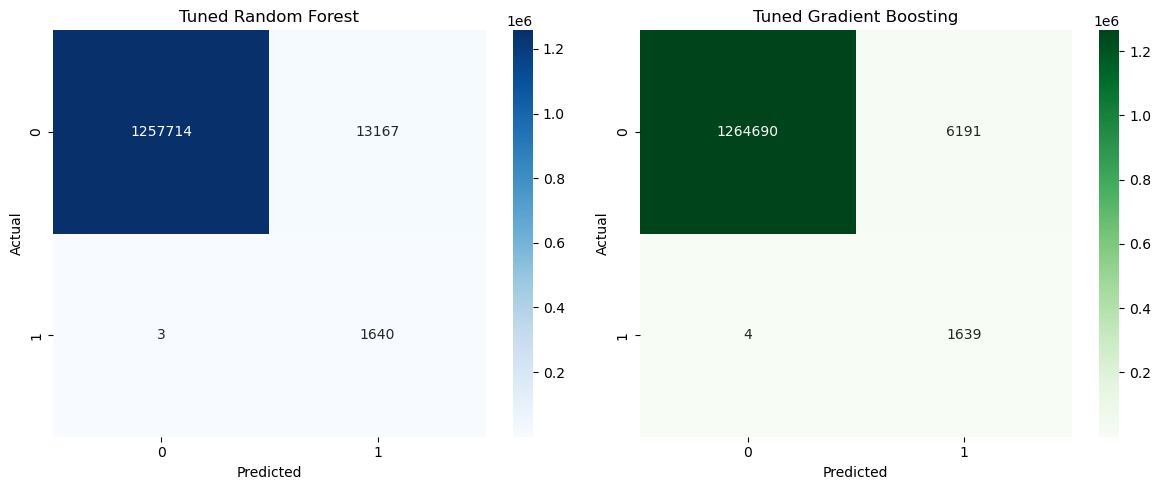

In [30]:
# Creating confusion matrices
cm_rf = confusion_matrix(y_test, rf_final_preds)   # tuned Random Forest
cm_gb = confusion_matrix(y_test, gb_final_preds)   # tuned Gradient Boosting

# Creating side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest plot
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Tuned Random Forest")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Gradient Boosting plot
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Tuned Gradient Boosting")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

# Saving chart image to docs folder
plt.savefig("../docs/confusion_matrix.png", bbox_inches='tight')

#Displaying the chart
plt.show()

<u>Insights:</u>
* Both models are extremely good at identifying normal transactions, with very high true negatives in both cases.
* *Random Forest catches more fraud cases* (1117 vs 1061), meaning it has better recall and *misses fewer fraudulent transactions*.
* *Gradient Boosting produces more false alarms* (276 vs 23), so it flags more normal transactions as fraud compared to Random Forest.
* Overall, *Random Forest performs better for fraud detection* since it balances catching fraud and minimizing false positives more effectively.

### Feature Importance:
Feature importance shows which variables had the biggest impact on the model’s decision-making in detecting fraud. I'll be using Random Forest for Feautre Importance because it provides more stable and easily interpretable importance scores compared to Gradient Boosting.

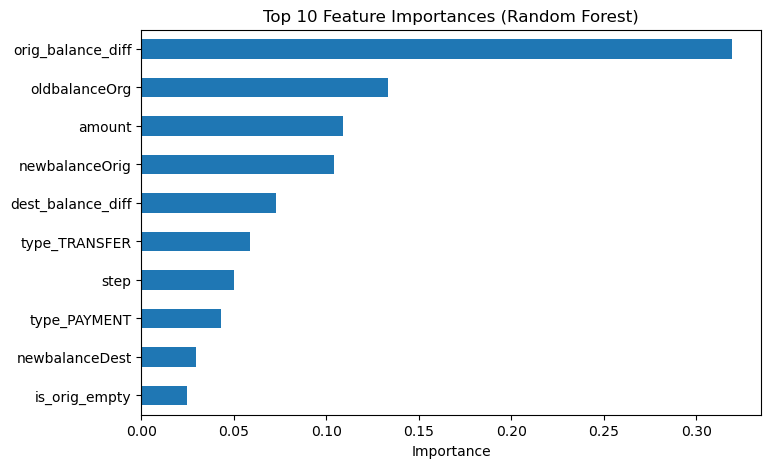

In [31]:
# Getting feature importances from tuned Random Forest
importances = best_rf.feature_importances_

# Getting feature names from my dataset
features = X_train.columns

# Creating a sorted Series of feature importances
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

# Plotting top 10 most important features
plt.figure(figsize=(8, 5))
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()  # highest importance on top
plt.savefig("../docs/feature_importance.png", bbox_inches='tight')
plt.show()

<u>Insights:</u>
* The most important feature is `orig_balance_diff`, which means changes in the sender’s balance are a strong indicator of fraud, fraud transactions often create unusual balance differences.
* Features related to the sender’s account like `oldbalanceOrg` and `newbalanceOrig` are highly influential, showing that fraud is strongly tied to how money moves out of the origin account.
* Transaction amount (`amount`) also plays a big role, suggesting that larger or unusual transaction sizes are more likely to be flagged as fraud.
* Transaction type (like TRANSFER) has some impact, but overall numerical balance features matter more than transaction type, meaning behavior patterns are more important than categories.

### Summary:
In this notebook, I focused on building and improving a machine learning model to detect fraudulent transactions. One thing I immediately noticed is how imbalanced the dataset is, only about 0.13% of transactions are fraud, so the challenge was really about catching those rare cases without missing too many.

I split the data into training and testing sets (about 5M+ for training and 1.2M+ for testing) and trained two models: Random Forest and Gradient Boosting. These are both strong models for structured data, so I wanted to see which one performs better for this problem.

For the baseline results, Random Forest performed really well with an F1 score of ~0.88, while Gradient Boosting was lower at ~0.65. From this, it was clear that Random Forest was better at identifying fraud cases initially, especially in balancing precision and recall.

After that, I applied RandomizedSearchCV to tune both models and find better hyperparameters. Interestingly, the results showed that tuning didn’t always improve performance across the board. The tuned Random Forest actually dropped to ~0.80 F1, while tuned Gradient Boosting improved to ~0.71.

So overall, even after tuning, Random Forest still ended up being the best-performing model, although Gradient Boosting became more competitive after optimization.

This whole process helped me understand that:
	•	Strong baseline models can sometimes already be near optimal
	•	Hyperparameter tuning doesn’t always guarantee improvement
	•	And for imbalanced problems like fraud detection, F1 score really helps capture the real performance of the model

Overall, this notebook gave me a better feel for how model selection and tuning actually impact results in a real-world scenario.
